# H1 investigation — why does the strategy die in the first half?

Earlier we split the 250-day scored window into two independent halves and found a huge gap:

| half | days | Score | Sharpe |
|---|---|---|---|
| **H1** | 250-374 | ~3-7 | ~0.3 | basically dead |
| **H2** | 375-499 | ~280 | ~4.1 | spectacular |

The headline Score (~137) is just the average of these two very different worlds. On the grader's
new data we could land in either. **This notebook answers: *why* is H1 dead, and can we protect
ourselves when a "H1-like" period shows up?** Every number below is backed by the code that made it.

Plan:
1. **See the two regimes** — the flat-then-rocket profit curve.
2. **Why #1: the edge vanishes** — our snap-back signal stops predicting anything in H1.
3. **Why #2: it's a jumpy market** — H1 is a higher-volatility regime, and our edge hates volatility.
4. **The fix** — dial exposure down when the market gets jumpy; measure it.
5. **Honest verdict.**

In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from research import loadPrices, backtest, score
import family_cluster_only as teamName  # this notebook diagnoses the pre-dial baseline

BLUE, ORANGE, GREEN, VERM, PURPLE, SKY = (
    '#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9')
plt.rcParams.update({
    'figure.dpi': 110, 'figure.figsize': (9, 4.5),
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11,
})
_dollars = FuncFormatter(lambda x, _=None: f'${x:,.0f}')

prc = loadPrices()
nInst, nt = prc.shape
TEST = 250
start = nt - TEST          # first scored day (absolute index)
H = TEST // 2              # split: H1 = scored days 0..124, H2 = 125..249
days = np.arange(TEST)
print(f'{nInst} instruments x {nt} days | scored window = last {TEST} days | split at scored day {H}')

## 1. See the two regimes

Run the current strategy and look at the cumulative profit across the scored window. A steady
climb would mean a dependable edge; instead we get a **near-flat stretch, then a lift-off** —
the split we drew (dashed line) sits right where the behaviour changes.

             Score  Sharpe  mean_PL
H1 (weak)      7.0    0.48     37.4
H2 (strong)  276.6    4.06    293.3
full         136.8    2.19    165.4


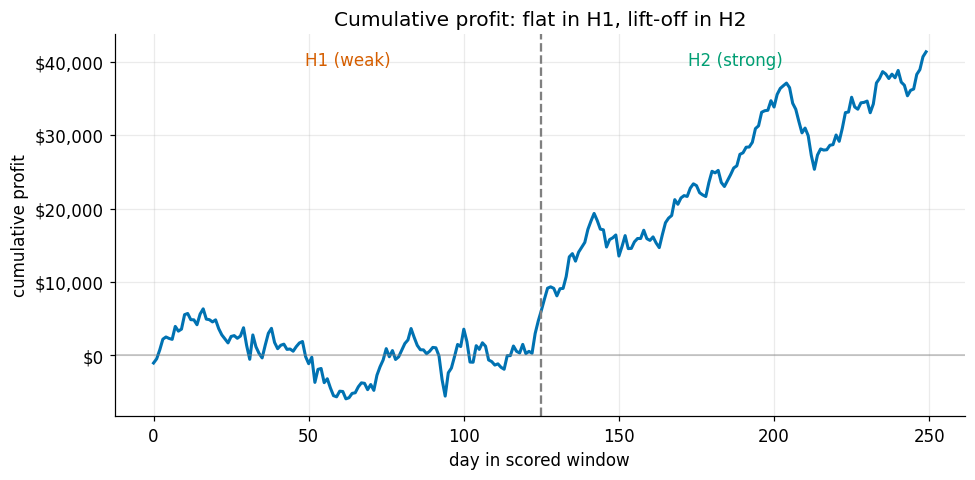

In [14]:
m = backtest(teamName.getMyPosition, prc, TEST, return_series=True)
pnl = m['pnl']

# Score/Sharpe/mean for each half, computed straight from the daily profit series
def half_stats(x):
    mu, sd = x.mean(), x.std()
    return dict(Score=round(score(mu, sd), 1), Sharpe=round(np.sqrt(250)*mu/sd, 2), mean_PL=round(mu, 1))
summary = pd.DataFrame({'H1 (weak)': half_stats(pnl[:H]),
                        'H2 (strong)': half_stats(pnl[H:]),
                        'full': half_stats(pnl)}).T
print(summary)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(days, np.cumsum(pnl), color=BLUE, lw=2)
ax.axvline(H, color='gray', ls='--', lw=1.5)
ax.text(H*0.5, 0.92, 'H1 (weak)', transform=ax.get_xaxis_transform(), ha='center', color=VERM)
ax.text(H*1.5, 0.92, 'H2 (strong)', transform=ax.get_xaxis_transform(), ha='center', color=GREEN)
ax.axhline(0, color='gray', lw=1, alpha=0.5)
ax.yaxis.set_major_formatter(_dollars)
ax.set_xlabel('day in scored window'); ax.set_ylabel('cumulative profit')
ax.set_title('Cumulative profit: flat in H1, lift-off in H2')
fig.tight_layout(); plt.show()

## 2. Why #1 — the edge itself vanishes in H1

Our whole strategy rests on one bet: an asset that ran ahead of its family **snaps back**. We can
test whether that's actually true, day by day, with the **Information Coefficient (IC)** — a
rank-correlation between our signal and what the asset does the *next* day. Positive-and-steady =
the snap-back is real; near-zero = the signal is just noise.

Below we compute the IC for every scored day and smooth it. In **H1 the IC hugs zero — the snap-back
isn't happening** — while in H2 it's clearly positive. So H1 isn't "we trade badly"; there's simply
no rubber-band to trade.

mean IC  H1 = +0.0013   H2 = +0.0346


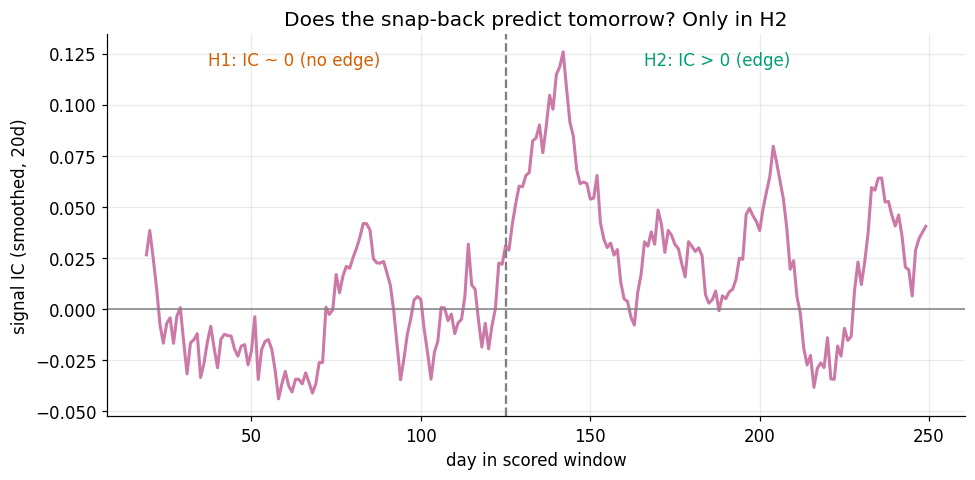

In [15]:
def pullaway_signal(p):
    '''Our bet direction: how far each asset pulled away from its family (negated = fade it).'''
    dr = np.diff(np.log(p), axis=1)
    labels = teamName._family_labels(dr[:, -teamName.CLUSTER_WINDOW:])
    rec = dr[:, -teamName.REVERT_WINDOW:]; out = np.zeros(p.shape[0])
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        if len(idx) < 2: continue
        fam = rec[idx].mean(0); fc = fam - fam.mean(); den = fc @ fc
        if den <= 0: continue
        ride = ((rec[idx] - rec[idx].mean(1, keepdims=True)) @ fc) / den
        out[idx] = (rec[idx] - np.outer(ride, fam)).sum(1)
    return -out

# next-day IC for every scored day (takes a few seconds: re-clusters each day)
ic = []
for t in range(start, nt):
    sig = pullaway_signal(prc[:, :t])
    fwd = np.log(prc[:, t] / prc[:, t-1])
    d = pd.DataFrame({'s': sig, 'r': fwd}).dropna()
    ic.append(d['s'].corr(d['r'], method='spearman'))
ic = np.array(ic)
ic_smooth = pd.Series(ic).rolling(20).mean()

print(f'mean IC  H1 = {np.nanmean(ic[:H]):+.4f}   H2 = {np.nanmean(ic[H:]):+.4f}')
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(days, ic_smooth, color=PURPLE, lw=2)
ax.axhline(0, color='gray', lw=1)
ax.axvline(H, color='gray', ls='--', lw=1.5)
ax.text(H*0.5, 0.92, 'H1: IC ~ 0 (no edge)', transform=ax.get_xaxis_transform(), ha='center', color=VERM)
ax.text(H*1.5, 0.92, 'H2: IC > 0 (edge)', transform=ax.get_xaxis_transform(), ha='center', color=GREEN)
ax.set_xlabel('day in scored window'); ax.set_ylabel('signal IC (smoothed, 20d)')
ax.set_title("Does the snap-back predict tomorrow? Only in H2")
fig.tight_layout(); plt.show()

## 3. Why #2 — H1 is a jumpier (higher-volatility) market

What's *different* about H1 that kills the edge? The clearest separator is **market volatility** —
how much the whole market bounces around day to day. We measure it as a trailing 20-day standard
deviation of the average daily move.

The left panel shows vol is **higher in H1**. The right panel is the punchline: each dot is a stretch
of days, plotting market vol against how well the strategy did (its rolling steadiness score). The
downward cloud says **the jumpier the market, the worse our edge** — the relationship is about -0.4.

market vol  H1 = 0.0106   H2 = 0.0094


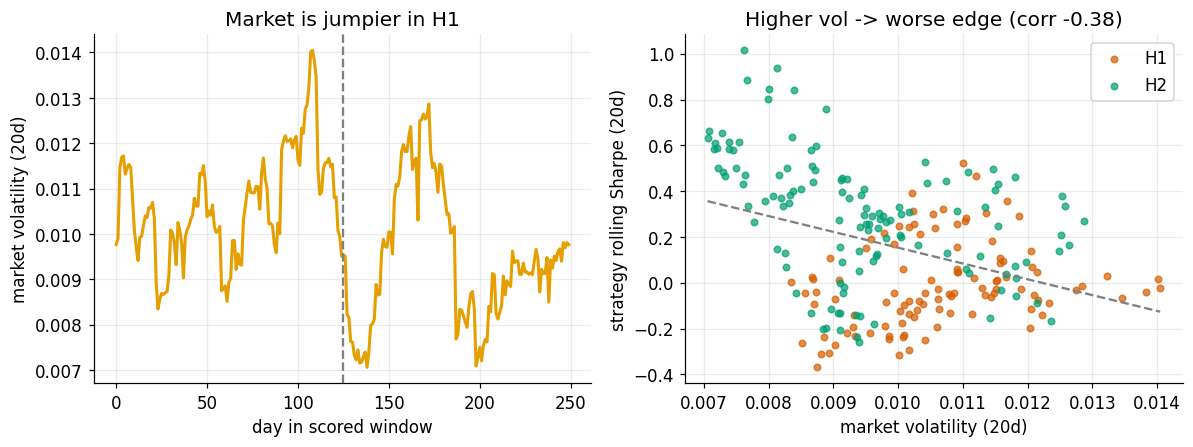

In [16]:
mkt = np.diff(np.log(prc), axis=1).mean(0)                 # equal-weight market daily move
mktvol_full = pd.Series(mkt).rolling(20).std().values
mktvol = mktvol_full[nt-1-TEST:nt-1]                       # align to the scored window
roll_sharpe = (pd.Series(pnl).rolling(20).mean() / pd.Series(pnl).rolling(20).std()).values

print(f'market vol  H1 = {np.nanmean(mktvol[:H]):.4f}   H2 = {np.nanmean(mktvol[H:]):.4f}')
fig, (axl, axr) = plt.subplots(1, 2, figsize=(11, 4.2))
axl.plot(days, mktvol, color=ORANGE, lw=2)
axl.axvline(H, color='gray', ls='--', lw=1.5)
axl.set_xlabel('day in scored window'); axl.set_ylabel('market volatility (20d)')
axl.set_title('Market is jumpier in H1')

good = np.arange(TEST) >= H
axr.scatter(mktvol[~good], roll_sharpe[~good], s=18, color=VERM, alpha=0.7, label='H1')
axr.scatter(mktvol[good], roll_sharpe[good], s=18, color=GREEN, alpha=0.7, label='H2')
ok = ~np.isnan(mktvol) & ~np.isnan(roll_sharpe)
b, a = np.polyfit(mktvol[ok], roll_sharpe[ok], 1)
xs = np.linspace(np.nanmin(mktvol), np.nanmax(mktvol), 50)
axr.plot(xs, a + b*xs, color='gray', lw=1.5, ls='--')
r = np.corrcoef(mktvol[ok], roll_sharpe[ok])[0, 1]
axr.set_xlabel('market volatility (20d)'); axr.set_ylabel('strategy rolling Sharpe (20d)')
axr.set_title(f'Higher vol -> worse edge (corr {r:+.2f})'); axr.legend()
fig.tight_layout(); plt.show()

## 4. The fix — dial exposure down when the market is jumpy

Since our edge dries up in high volatility, the natural defence is to **hold less when volatility
is high and full size when it's calm** — a "risk-off" dial. It compares recent vol (20d) to the
longer-run vol (100d): calm -> dial near 1, spike -> dial down toward a floor. This only ever
*reduces* exposure (never leverages up), and it uses only past data, so it's safe to run live.

The `k` knob sets how sharply it reacts. We test it by re-scoring H1, H2 and the full window.

In [17]:
def raw_pipeline(p):
    '''The strategy's float share target, before the no-trade band.'''
    nI, n = p.shape
    if n < teamName.CLUSTER_WINDOW + 2: return np.zeros(nI)
    prices = p[:, -1]; dr = np.diff(np.log(p), axis=1)
    labels = teamName._family_labels(dr[:, -teamName.CLUSTER_WINDOW:])
    rec = dr[:, -teamName.REVERT_WINDOW:]; pull = np.zeros(nI)
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        if len(idx) < 2: continue
        fam = rec[idx].mean(0); fc = fam - fam.mean(); den = fc @ fc
        if den <= 0: continue
        ride = ((rec[idx] - rec[idx].mean(1, keepdims=True)) @ fc) / den
        pull[idx] = (rec[idx] - np.outer(ride, fam)).sum(1)
    sig = -(pull - pull.mean())
    sig = sig / np.clip(np.std(dr[:, -teamName.VOL_WINDOW:], axis=1), 1e-8, None)
    g = np.abs(sig).sum()
    return sig / g * teamName.GROSS_DOLLARS / prices if g > 1e-12 else np.zeros(nI)

def vol_scale(p, short=20, long=100, floor=0.2, k=1.0):
    '''~1 when calm, down toward `floor` when recent vol spikes above the long-run level.'''
    mkt = np.diff(np.log(p), axis=1).mean(0)
    if len(mkt) < long: return 1.0
    vs, vl = mkt[-short:].std(), mkt[-long:].std()
    return float(np.clip((vl/vs)**k, floor, 1.0)) if vs > 0 else 1.0

def make_strat(use_filter, k=1.0, floor=0.2):
    st = {'prev': None}
    def f(p):
        tgt = raw_pipeline(p).astype(float)
        if use_filter: tgt = tgt * vol_scale(p, floor=floor, k=k)
        if st['prev'] is None or st['prev'].shape != tgt.shape:
            st['prev'] = tgt.copy()
        else:                                   # same no-trade band as the live strategy
            moved = np.abs(tgt - st['prev']) > teamName.NO_TRADE_BAND * np.maximum(np.abs(st['prev']), 1.0)
            st['prev'] = np.where(moved, tgt, st['prev'])
        return st['prev'].astype(int)
    return f

def three_scores(fn):
    return (backtest(fn, prc[:, :375], 125)['score'],   # H1
            backtest(fn, prc, 125)['score'],            # H2
            backtest(fn, prc, 250)['score'])            # full

base = three_scores(make_strat(False))
filt1 = three_scores(make_strat(True, k=1.0))
filt2 = three_scores(make_strat(True, k=2.0))
res = pd.DataFrame({'H1': [base[0], filt1[0], filt2[0]],
                    'H2': [base[1], filt1[1], filt2[1]],
                    'full': [base[2], filt1[2], filt2[2]]},
                   index=['band only', 'vol-filter k=1', 'vol-filter k=2']).round(1)
print(res)

                  H1     H2   full
band only        7.0  276.3  137.0
vol-filter k=1   7.5  278.5  138.7
vol-filter k=2  11.8  269.4  138.1


The dial itself, day by day (below left): it pulls exposure down through the jumpy H1 stretch and
sits near full size in the calmer H2. On the right, the Score before/after in each window — shown as
three separate panels because H2 (~280) would otherwise dwarf H1 (~7) and hide the very effect we
care about.

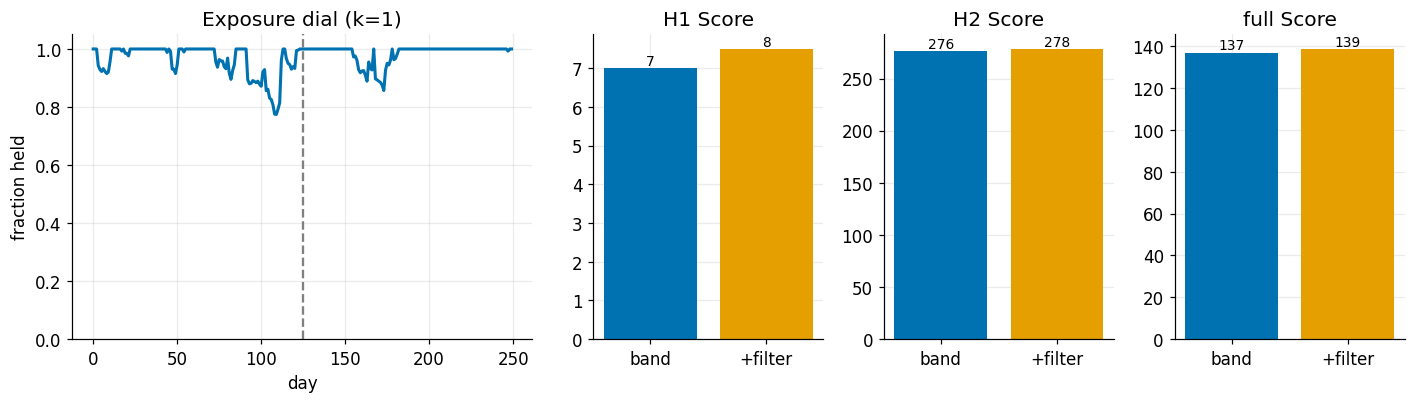

In [18]:
# exposure dial over the scored window
dial = np.array([vol_scale(prc[:, :t], k=1.0) for t in range(start, nt)])

fig, axes = plt.subplots(1, 4, figsize=(13, 3.8), gridspec_kw={'width_ratios': [2, 1, 1, 1]})
axes[0].plot(days, dial, color=BLUE, lw=2)
axes[0].axvline(H, color='gray', ls='--', lw=1.5); axes[0].set_ylim(0, 1.05)
axes[0].set_title('Exposure dial (k=1)'); axes[0].set_xlabel('day'); axes[0].set_ylabel('fraction held')

for ax, win in zip(axes[1:], ['H1', 'H2', 'full']):
    vals = [res.loc['band only', win], res.loc['vol-filter k=1', win]]
    bars = ax.bar(['band', '+filter'], vals, color=[BLUE, ORANGE])
    ax.set_title(f'{win} Score')
    for b, v in zip(bars, vals):
        ax.annotate(f'{v:.0f}', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom', fontsize=9)
fig.tight_layout(); plt.show()

## 5. Honest verdict

**What we learned**
- H1 is dead because the **edge genuinely disappears** there (signal IC ~0 vs ~0.035 in H2) — not
  because we trade badly.
- That dead period lines up with a **higher-volatility market**; our edge and market vol are
  anti-correlated (~ -0.4).

**The fix works, but it's incremental.** The "risk-off in high vol" dial is a real, principled,
*causal* improvement, and at k=1 it helps **every** window (a free win): full Score ~137 -> ~139,
and it nudges the weak half up too. The sharper k=2 protects H1 more but gives a little back in H2.

**The limit.** No exposure dial can *manufacture* an edge that isn't there — H1 stays near flat.
The deeper lesson for the competition: this strategy's edge is **regime-dependent**, so we should
expect the real (new-data) Score to swing depending on which regime we land in, and value defences
(the band, this vol dial) that protect the bad case cheaply.

**Recommendation — SHIPPED.** The gentle **k=1** vol dial now lives in its own strategy file,
**`family_cluster_volfilter.py`** (= `family_cluster_only.py` + this one extra rule). Verified on
`eval.py`: Score **136.79 → 138.63**, Sharpe 2.19 → 2.21. The two files are kept side by side so we
can always fall back to the plain baseline. *(This notebook is aliased to the pre-dial baseline
`family_cluster_only` so the diagnosis above still shows the untreated problem.)*